In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import sys
sys.path.append('../src') 

from model import TerrainGenerator
from config import LATENT_DIM, TILE_SIZE, CONDITION_WIDTH

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

# Initialize the architecture using TerrainGenerator
generator = TerrainGenerator(LATENT_DIM).to(device)

# Load the weights 
weights_path = '../models/generatorcGAN2.pth'
state_dict = torch.load(weights_path, map_location=device)

generator.load_state_dict(state_dict)
generator.eval()
print("Weights loaded successfully!")

Testing on: cuda
Weights loaded successfully!


Stitched terrain shape: (3, 256, 480)
Elevation Min: 0.00, Max: 0.53


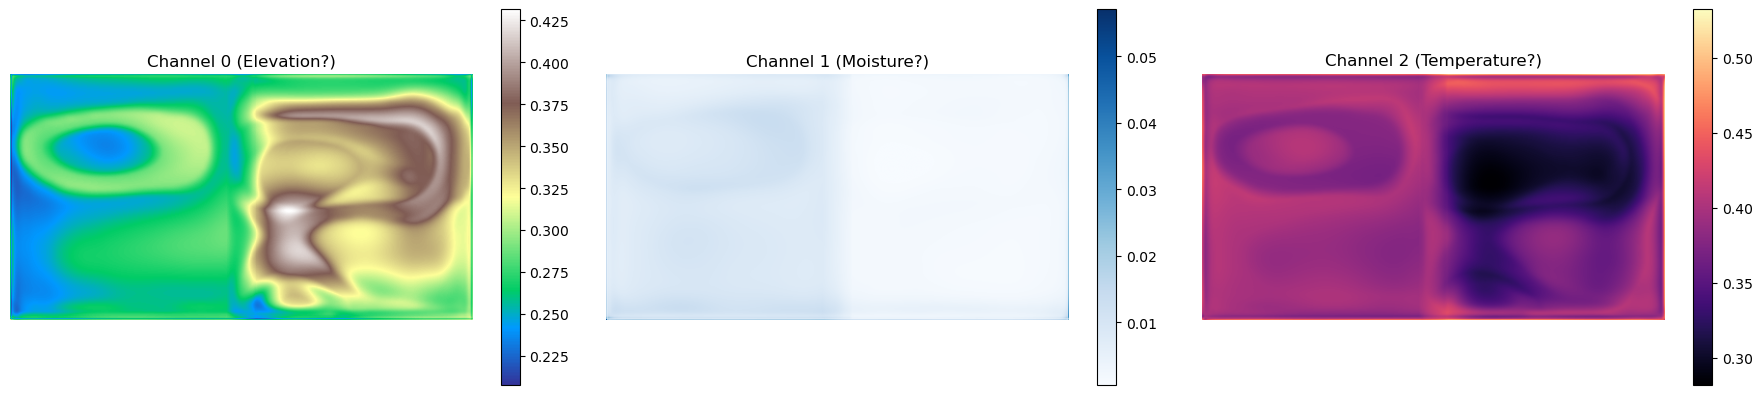

In [ ]:
import torch

# --- TILE 1 GENERATION ---
mask_1 = torch.zeros(1, 1, TILE_SIZE, TILE_SIZE, device=device)
condition_1 = torch.zeros(1, 3, TILE_SIZE, TILE_SIZE, device=device)
# Note: If you want the left tile to change across runs, ensure noise_1 
# is re-rolled every time this cell is executed.
noise_1 = torch.randn(1, LATENT_DIM, 1, 1, device=device)

with torch.no_grad():
    tile_1 = generator(noise_1, condition_1, mask_1)

# --- TILE 2 PREPARATION ---
mask_2 = torch.zeros(1, 1, TILE_SIZE, TILE_SIZE, device=device)
mask_2[:, :, :, :CONDITION_WIDTH] = 1.0 

condition_2 = torch.zeros(1, 3, TILE_SIZE, TILE_SIZE, device=device)
condition_2[:, :, :, :CONDITION_WIDTH] = tile_1[:, :, :, -CONDITION_WIDTH:]

# --- FORCE VARIANCE ---
# We are using completely un-interpolated, 100% fresh noise. 
# If the right tile STILL looks identical across generations, 
# your model has completely collapsed into ignoring the latent space.
noise_2 = torch.randn(1, LATENT_DIM, 1, 1, device=device)

with torch.no_grad():
    tile_2 = generator(noise_2, condition_2, mask_2)

# --- REVERTED: Smooth Alpha Blending ---
overlap_1 = tile_1[:, :, :, -CONDITION_WIDTH:]
overlap_2 = tile_2[:, :, :, :CONDITION_WIDTH]

# Clean, linear 1D gradient with no jitter
alpha = torch.linspace(1.0, 0.0, CONDITION_WIDTH, device=device).view(1, 1, 1, CONDITION_WIDTH)

blended_overlap = (overlap_1 * alpha) + (overlap_2 * (1.0 - alpha))

# Assemble the final stitched tensor
left_part = tile_1[:, :, :, :-CONDITION_WIDTH]
right_part = tile_2[:, :, :, CONDITION_WIDTH:]

stitched_tensor = torch.cat([left_part, blended_overlap, right_part], dim=3)

# Move to CPU and convert to NumPy
terrain_map = stitched_tensor.squeeze().cpu().numpy()

print(f"Stitched terrain shape: {terrain_map.shape}")
print(f"Elevation Min: {terrain_map.min():.2f}, Max: {terrain_map.max():.2f}")

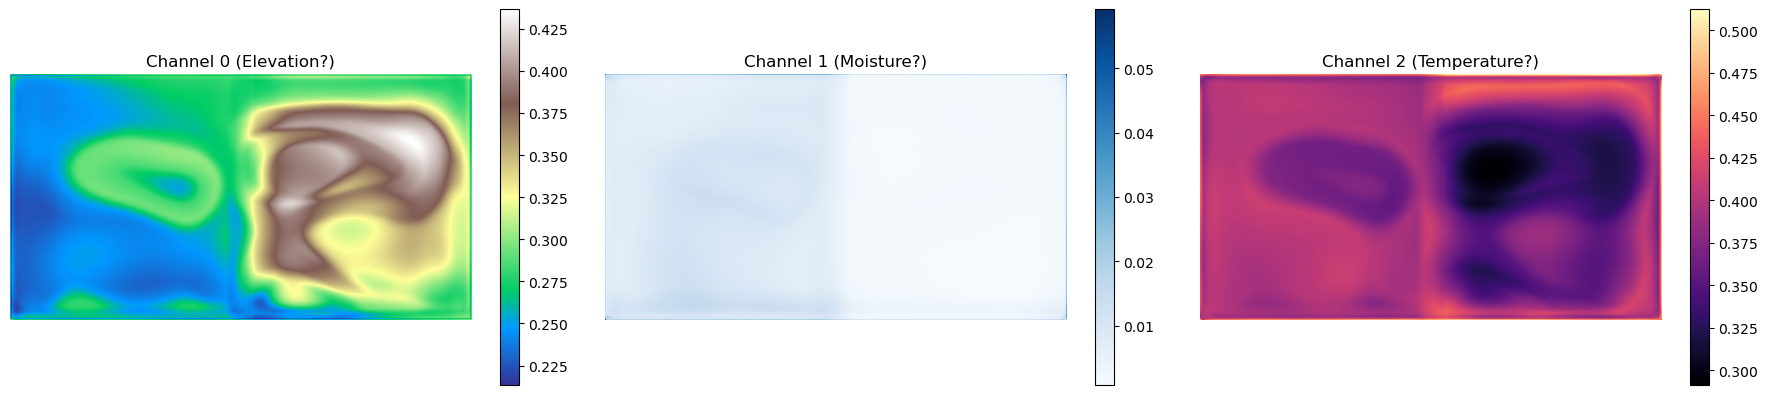

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(terrain_map[0], cmap='terrain')
axes[0].set_title("Channel 0 (Elevation?)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(terrain_map[1], cmap='Blues')
axes[1].set_title("Channel 1 (Moisture?)")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(terrain_map[2], cmap='magma')
axes[2].set_title("Channel 2 (Temperature?)")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
import pyvista as pv
import numpy as np

pv.set_jupyter_backend('trame') 

elevation = terrain_map[0]

x = np.arange(0, elevation.shape[1], 1)
y = np.arange(0, elevation.shape[0], 1)
x, y = np.meshgrid(x, y)

z_exaggeration = 50.0 
z = elevation * z_exaggeration

grid = pv.StructuredGrid(x, y, z)

grid.point_data["Elevation"] = elevation.flatten(order="F")

plotter = pv.Plotter(window_size=[800, 600])

plotter.add_mesh(
    grid, 
    scalars="Elevation",
    cmap="terrain",
    show_edges=False,
    lighting=True
)

plotter.add_axes()
plotter.set_background('white')

plotter.show()

C:\Users\Orzeł\AppData\Local\Temp\ipykernel_5864\2924208182.py:15: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(x, y, z)


Widget(value='<iframe src="http://localhost:63387/index.html?ui=P_0x18aefd66990_4&reconnect=auto" class="pyvis…